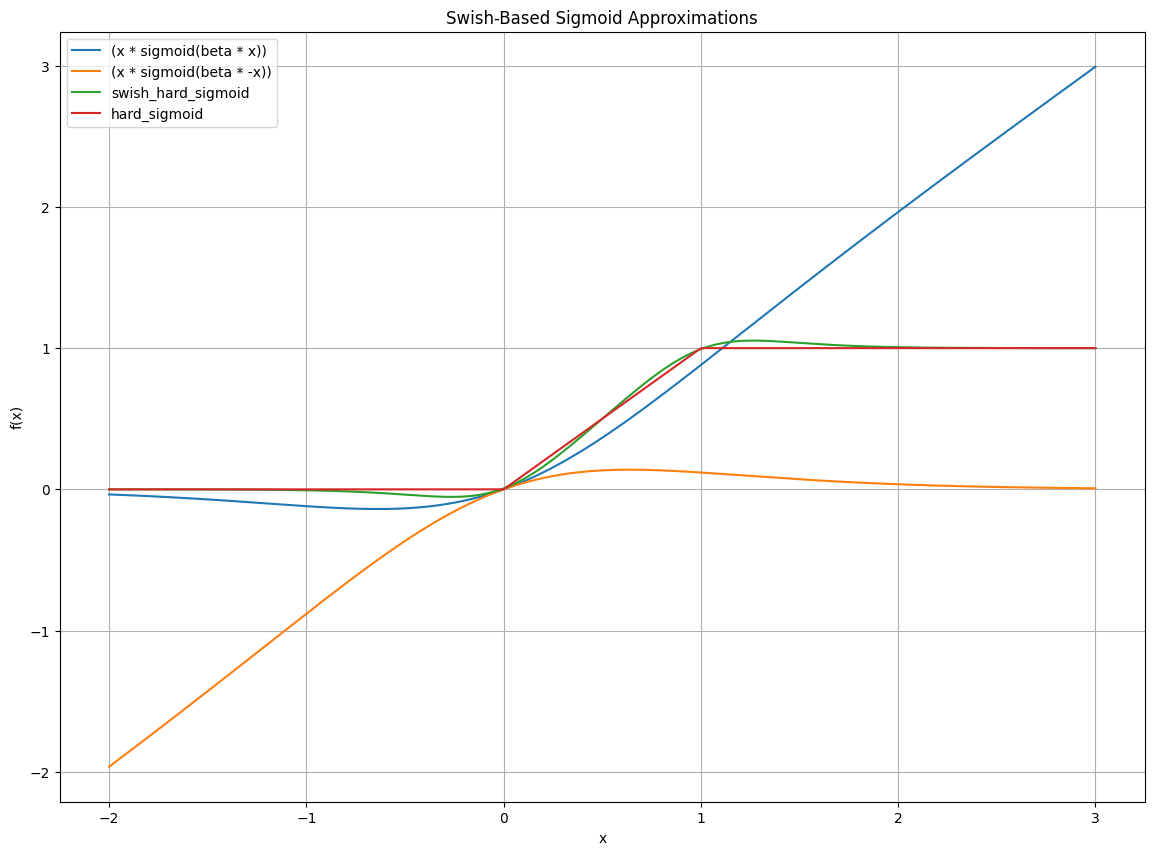

Text(0, 0.5, 'f(x)')

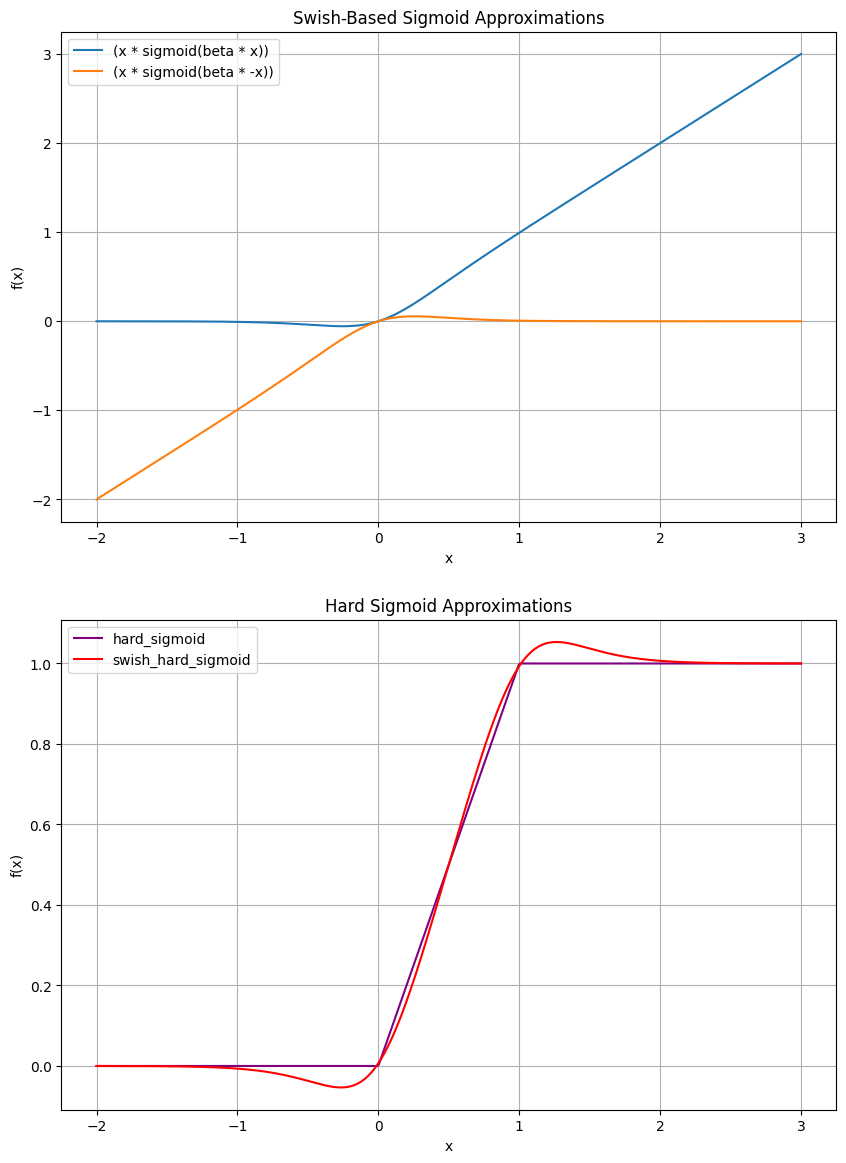

In [2]:
import matplotlib.pyplot as plt
import torch


def swish(x, beta=1.0):
    return x * torch.sigmoid(beta * x)
def negative_swish(x, beta=1.0):
    return x * torch.sigmoid(beta * -x)
def upside_down_swish(x, beta=1.0):
    return (x * torch.sigmoid(beta * -x))
def swish_hard_sigmoid(x, beta=1.0, scale=1.0, xshift=0.5, yshift=0.5):
    x = x - xshift
    return yshift + (upside_down_swish(x-scale, beta) - swish(x, beta))  + (swish(x+scale, beta) - upside_down_swish(x, beta))
def hard_sigmoid(x):
    return torch.clamp(x, min=0, max=1)
x = torch.linspace(-2, 3, 500)
plt.figure(figsize=(14, 10))
# plt.plot(x.numpy(), std_sig.numpy(), label='Standard Sigmoid', linestyle='--')
plt.plot(x.numpy(), swish(x, beta=2.0).numpy(), label='(x * sigmoid(beta * x))')
plt.plot(x.numpy(), upside_down_swish(x, beta=2.0).numpy(), label='(x * sigmoid(beta * -x))')
plt.plot(x.numpy(), swish_hard_sigmoid(x, beta=5.0, scale=0.5, xshift=0.5, yshift=0.5).numpy(), label='swish_hard_sigmoid')
plt.plot(x.numpy(), hard_sigmoid(x).numpy(), label='hard_sigmoid')
#plt.plot(x.numpy(), v3.numpy(), label='Swish Hard Sigmoid v3')
plt.legend()
plt.grid(True)
plt.title("Swish-Based Sigmoid Approximations")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()
# Now we plot the same lines, but split the swish and upside down swish into one plot and the hard sigmoids into another plot, using subplots
plt.figure(figsize=(10, 14))
plt.subplot(2, 1, 1)
plt.plot(x.numpy(), swish(x, beta=5.0).numpy(), label='(x * sigmoid(beta * x))')
plt.plot(x.numpy(), upside_down_swish(x, beta=5.0).numpy(), label='(x * sigmoid(beta * -x))')
plt.legend()
plt.grid(True)
plt.title("Swish-Based Sigmoid Approximations")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.subplot(2, 1, 2)
plt.plot(x.numpy(), hard_sigmoid(x).numpy(), label='hard_sigmoid', color='purple')
plt.plot(x.numpy(), swish_hard_sigmoid(x, beta=5.0, scale=0.5, xshift=0.5, yshift=0.5).numpy(), label='swish_hard_sigmoid', color='red')
plt.legend()
plt.grid(True)
plt.title("Hard Sigmoid Approximations")
plt.xlabel("x")
plt.ylabel("f(x)")
#plt.savefig("swish_sigmoid_approximations.png") (edited) 



In [ ]:
import torch.nn.functional as F
from torch import Tensor


def leaky_relu(x: Tensor, alpha: float = 0.01) -> Tensor:
    return torch.where(x > 0, x, alpha * x)
    # return F.leaky_relu(x, negative_slope=alpha)


def upper_leaky_relu(x: Tensor, alpha: float = 0.01) -> Tensor:
    """Small slope in the positive and negative regions."""
    # TODO: Make more memory efficient
    return torch.where(x > 1, 1 + alpha * (x - 1), F.relu(x))


x = torch.linspace(-5, 5, 100)

orig_forward = leaky_relu(torch.clamp(x, max=1))
forward_unclamped = upper_leaky_relu(x)


In [23]:
x_offset = 0.5
steepness = 5
sigmoid = torch.sigmoid(steepness*(x - x_offset))

In [ ]:
def upside_down_swish(x, beta=1.0):
    return (x * torch.sigmoid(beta * -x))

def swish(x, beta=1.0):
    return x * torch.sigmoid(beta * x)

def swish_hard_sigmoid(x, beta=1.0, scale=0.5, xshift=0.5, yshift=0.5):
    x = x - xshift
    return yshift + (upside_down_swish(x-scale, beta) - swish(x, beta))  + (swish(x+scale, beta) - upside_down_swish(x, beta))

swish_sigmoid = swish_hard_sigmoid(x, beta=5)

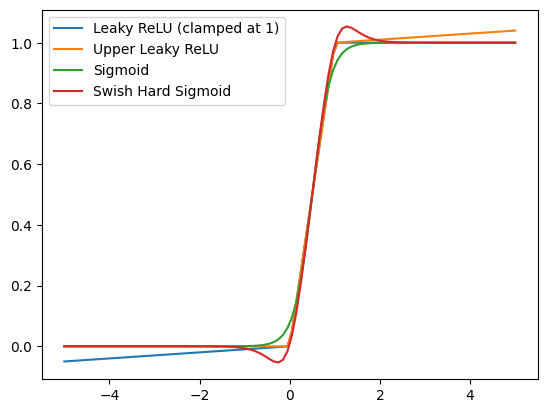

In [30]:
plt.plot(x.numpy(), orig_forward.numpy(), label='Leaky ReLU (clamped at 1)')
plt.plot(x.numpy(), forward_unclamped.numpy(), label='Upper Leaky ReLU')
plt.plot(x.numpy(), sigmoid.numpy(), label='Sigmoid')
plt.plot(x.numpy(), swish_sigmoid.numpy(), label='Swish Hard Sigmoid')
plt.legend()
